In [ ]:
# ===============================
# Seed Configuration (Reproducibility)
# ===============================

import random
import numpy as np
import torch

SEED = 42

# Python random seed
random.seed(SEED)

# NumPy seed
np.random.seed(SEED)

# PyTorch CPU seed
torch.manual_seed(SEED)

# PyTorch GPU seed
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED}")

/opt/conda/lib/python3.7/site-packages/torchvision/transforms/transforms.py:330: UserWarning: Argument 'interpolation' of type int is deprecated since 0.13 and will be removed in 0.15. Please use InterpolationMode enum.
  "Argument 'interpolation' of type int is deprecated since 0.13 and will be removed in 0.15. "



========== DRYWALL DATASET ==========
Train: 738
Validation: 82
Test: 202

========== CRACKS DATASET ==========
Train: 5164
Validation: 201
Test: 4

========== COMBINED DATASET ==========
Train: 5902
Validation: 283
Test: 206

Train Prompt Distribution
Counter({'segment crack': 5164, 'segment taping area': 738})

Validation Prompt Distribution
Counter({'segment crack': 201, 'segment taping area': 82})

Test Prompt Distribution
Counter({'segment taping area': 202, 'segment crack': 4})

Train Mask Distribution
{'background_pixels': 2273656825, 'object_pixels': 143802375}

Validation Mask Distribution
{'background_pixels': 106656910, 'object_pixels': 9259890}

Test Mask Distribution
{'background_pixels': 71210629, 'object_pixels': 13166971}

Showing 2 samples from Train


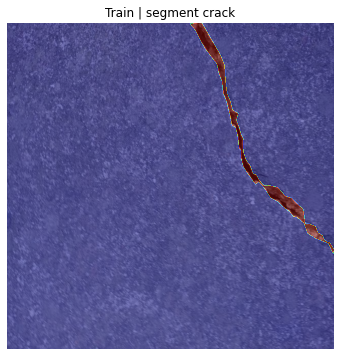

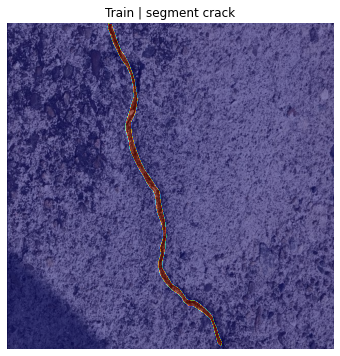


Showing 2 samples from Validation


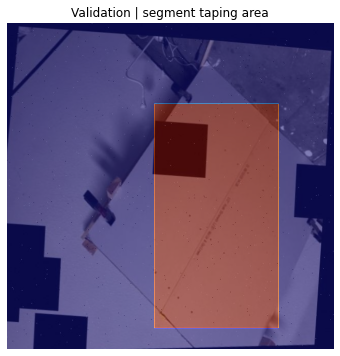

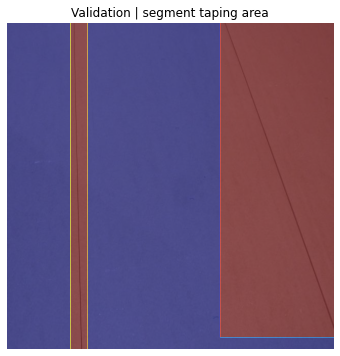


Showing 2 samples from Test


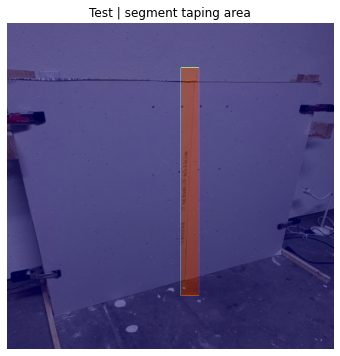

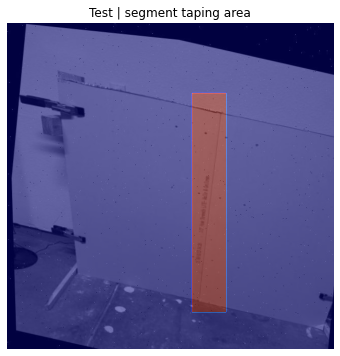

In [3]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset, random_split
from collections import Counter
from datalaoder import COCODataset
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

def collate_fn(batch):
    return tuple(zip(*batch))


NUM_WORKERS = 4
BATCH_SIZE = 32


# -------------------------
# Drywall dataset (bbox)
# -------------------------

drywall_train_full = COCODataset(
    root_dir="Drywall-Join-Detect.coco_origin_robotics/train",
    annotation_file="Drywall-Join-Detect.coco_origin_robotics/train/_annotations.coco.json",
    annotation_type="bbox",
    prompt="segment taping area"
)

train_size = int(0.9 * len(drywall_train_full))
val_size = len(drywall_train_full) - train_size

drywall_train, drywall_val = random_split(
    drywall_train_full,
    [train_size, val_size]
)

drywall_test = COCODataset(
    root_dir="Drywall-Join-Detect.coco_origin_robotics/valid",
    annotation_file="Drywall-Join-Detect.coco_origin_robotics/valid/_annotations.coco.json",
    annotation_type="bbox",
    prompt="segment taping area"
)


# -------------------------
# Cracks dataset (polygon)
# -------------------------

cracks_train = COCODataset(
    root_dir="cracks.v1i_origin_robotics/train",
    annotation_file="cracks.v1i_origin_robotics/train/_annotations.coco.json",
    annotation_type="polygon",
    prompt="segment crack"
)

cracks_val = COCODataset(
    root_dir="cracks.v1i_origin_robotics/valid",
    annotation_file="cracks.v1i_origin_robotics/valid/_annotations.coco.json",
    annotation_type="polygon",
    prompt="segment crack"
)

cracks_test = COCODataset(
    root_dir="cracks.v1i_origin_robotics/test",
    annotation_file="cracks.v1i_origin_robotics/test/_annotations.coco.json",
    annotation_type="polygon",
    prompt="segment crack"
)


# -------------------------
# Combine datasets
# -------------------------

train_dataset = ConcatDataset([drywall_train, cracks_train])
val_dataset = ConcatDataset([drywall_val, cracks_val])
test_dataset = ConcatDataset([drywall_test, cracks_test])


# -------------------------
# DataLoaders
# -------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS
)


# -------------------------
# Dataset sizes
# -------------------------

print("\n========== DRYWALL DATASET ==========")
print("Train:", len(drywall_train))
print("Validation:", len(drywall_val))
print("Test:", len(drywall_test))

print("\n========== CRACKS DATASET ==========")
print("Train:", len(cracks_train))
print("Validation:", len(cracks_val))
print("Test:", len(cracks_test))

print("\n========== COMBINED DATASET ==========")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


# -------------------------
# Prompt distribution
# -------------------------

def get_prompt_distribution(dataset):

    prompts = []

    for _, target in dataset:
        prompts.append(target["prompt"])

    return Counter(prompts)


print("\nTrain Prompt Distribution")
print(get_prompt_distribution(train_dataset))

print("\nValidation Prompt Distribution")
print(get_prompt_distribution(val_dataset))

print("\nTest Prompt Distribution")
print(get_prompt_distribution(test_dataset))


# -------------------------
# Mask distribution
# -------------------------

def get_mask_distribution(dataset):

    total_pixels = 0
    object_pixels = 0

    for _, target in dataset:

        mask = target["mask"]

        object_pixels += mask.sum().item()
        total_pixels += mask.numel()

    background_pixels = total_pixels - object_pixels

    return {
        "background_pixels": int(background_pixels),
        "object_pixels": int(object_pixels)
    }


print("\nTrain Mask Distribution")
print(get_mask_distribution(train_dataset))

print("\nValidation Mask Distribution")
print(get_mask_distribution(val_dataset))

print("\nTest Mask Distribution")
print(get_mask_distribution(test_dataset))


# -------------------------
# Visualization
# -------------------------

def show_samples(loader, split_name, num_samples=2):

    print(f"\nShowing {num_samples} samples from {split_name}")

    images, targets = next(iter(loader))

    for i in range(min(num_samples, len(images))):

        img = images[i].permute(1, 2, 0).numpy()
        mask = targets[i]["mask"].squeeze().numpy()
        prompt = targets[i]["prompt"]

        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.imshow(mask, alpha=0.5, cmap="jet")
        plt.title(f"{split_name} | {prompt}")
        plt.axis("off")
        plt.show()


show_samples(train_loader, "Train")
show_samples(val_loader, "Validation")
show_samples(test_loader, "Test")

In [4]:
print("\n==============================")
print("Loading CLIPSeg Model")
print("==============================")

from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

# Load processor
processor = CLIPSegProcessor.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)

# Load model
model = CLIPSegForImageSegmentation.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("\nModel Loaded Successfully\n")

# Print architecture
print(model)


Loading CLIPSeg Model

Model Loaded Successfully

CLIPSegForImageSegmentation(
  (clip): CLIPSegModel(
    (text_model): CLIPSegTextTransformer(
      (embeddings): CLIPSegTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPSegEncoder(
        (layers): ModuleList(
          (0): CLIPSegEncoderLayer(
            (self_attn): CLIPSegAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPSegMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)

In [3]:
import torch
import torch.nn.functional as F
import time
import pickle
import os
from tqdm import tqdm
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 101
LR = 1e-5

CHECKPOINT_PATH = "clipseg_checkpoint.pth"

log_file = open("training_log.txt", "a")

print("Loading CLIPSeg model...")
log_file.write("Loading CLIPSeg model...\n")


# ---------------------------
# Load CLIPSeg
# ---------------------------

processor = CLIPSegProcessor.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)

model = CLIPSegForImageSegmentation.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
).to(device)


# ---------------------------
# Optimizer
# ---------------------------

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)


# ---------------------------
# Scheduler
# ---------------------------

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=15,
    factor=0.5,
    verbose=True
)


# ---------------------------
# Resume Training if checkpoint exists
# ---------------------------

start_epoch = 0
best_val_loss = float("inf")

if os.path.exists(CHECKPOINT_PATH):

    print("Checkpoint found. Resuming training...")

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]

    print(f"Resuming from epoch {start_epoch}")

    log_file.write(f"Resuming training from epoch {start_epoch}\n")


# ---------------------------
# Loss Functions
# ---------------------------

def dice_loss(pred, target):

    pred = torch.sigmoid(pred)

    smooth = 1e-6

    intersection = (pred * target).sum()

    dice = (2 * intersection + smooth) / (
        pred.sum() + target.sum() + smooth
    )

    return 1 - dice


def weighted_bce_loss(pred, target):

    pos_weight = (target == 0).sum() / ((target == 1).sum() + 1e-6)

    return F.binary_cross_entropy_with_logits(
        pred,
        target,
        pos_weight=pos_weight
    )


def combined_loss(pred, target):

    bce = weighted_bce_loss(pred, target)
    dloss = dice_loss(pred, target)

    return bce + dloss


# ---------------------------
# Training
# ---------------------------

start_training_time = time.time()


for epoch in range(start_epoch, EPOCHS):

    epoch_start = time.time()

    model.train()

    train_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, targets in pbar:

        images = torch.stack(images).to(device)

        masks = torch.stack([t["mask"] for t in targets]).to(device)

        masks = F.interpolate(
            masks,
            size=(352,352),
            mode="nearest"
        )

        prompts = [t["prompt"] for t in targets]

        inputs = processor(
            text=prompts,
            images=images,
            return_tensors="pt",
            padding=True
        )

        inputs = {k:v.to(device) for k,v in inputs.items()}

        outputs = model(**inputs)

        pred = outputs.logits.unsqueeze(1)

        loss = combined_loss(pred, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pbar.set_postfix({"loss": loss.item()})

    train_loss /= len(train_loader)


    # ---------------------------
    # Validation
    # ---------------------------

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, targets in val_loader:

            images = torch.stack(images).to(device)

            masks = torch.stack([t["mask"] for t in targets]).to(device)

            masks = F.interpolate(
                masks,
                size=(352,352),
                mode="nearest"
            )

            prompts = [t["prompt"] for t in targets]

            inputs = processor(
                text=prompts,
                images=images,
                return_tensors="pt",
                padding=True
            )

            inputs = {k:v.to(device) for k,v in inputs.items()}

            outputs = model(**inputs)

            pred = outputs.logits.unsqueeze(1)

            loss = combined_loss(pred, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    epoch_time = time.time() - epoch_start


    # ---------------------------
    # Logging
    # ---------------------------

    log_msg = (
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Epoch Time: {epoch_time:.2f}s"
    )

    print(log_msg)
    log_file.write(log_msg + "\n")


    # ---------------------------
    # Save checkpoint
    # ---------------------------

    checkpoint = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_loss": best_val_loss
    }

    torch.save(checkpoint, CHECKPOINT_PATH)


    # ---------------------------
    # Save Best Model
    # ---------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_clipseg_model.pth"
        )

        metadata = {
            "best_epoch": epoch + 1,
            "best_val_loss": best_val_loss
        }

        with open("best_model_info.pkl", "wb") as f:
            pickle.dump(metadata, f)

        msg = f"Best model saved at epoch {epoch+1}"

        print(msg)
        log_file.write(msg + "\n")


# ---------------------------
# Total Training Time
# ---------------------------

total_training_time = time.time() - start_training_time

print(f"\nTraining completed in {total_training_time:.2f} seconds")

log_file.write(
    f"\nTotal training time: {total_training_time:.2f} seconds\n"
)

log_file.close()

Loading CLIPSeg model...


Epoch 1/101: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 185/185 [06:55<00:00,  2.25s/it, loss=1.94]


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 2/101:   0%|                                                                                                                                       | 0/185 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

...

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Epoch 101/101: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 185/185 [06:05<00:00,  1.65s/it, loss=1.68]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch 101/101: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 185/185 [06:05<00:00,  1.97s/it, loss=1.68]


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [5]:
import torch
import numpy as np
import cv2
import os
import csv
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -------------------------
# Create folders
# -------------------------

mask_dir = "predictions"
overlay_dir = "overlays"
triplet_dir = "triplet_visualizations"
comparison_dir = "gt_vs_prediction"

os.makedirs(mask_dir, exist_ok=True)
os.makedirs(overlay_dir, exist_ok=True)
os.makedirs(triplet_dir, exist_ok=True)
os.makedirs(comparison_dir, exist_ok=True)


# -------------------------
# Load model
# -------------------------

print("Loading trained CLIPSeg model...")

processor = CLIPSegProcessor.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)

model = CLIPSegForImageSegmentation.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)

model.load_state_dict(
    torch.load("best_clipseg_model.pth", map_location=device)
)

model = model.to(device)
model.eval()


# -------------------------
# Model statistics
# -------------------------

num_params = sum(p.numel() for p in model.parameters())
num_params_m = num_params / 1e6
model_size = os.path.getsize("best_clipseg_model.pth") / (1024*1024)


# -------------------------
# Metrics
# -------------------------

def dice_score(pred, target):

    pred = pred.flatten()
    target = target.flatten()

    intersection = (pred * target).sum()

    return (2 * intersection) / (
        pred.sum() + target.sum() + 1e-6
    )


def iou_score(pred, target):

    pred = pred.flatten()
    target = target.flatten()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum() - intersection

    return intersection / (union + 1e-6)


dice_scores = {"segment crack": [], "segment taping area": []}
iou_scores = {"segment crack": [], "segment taping area": []}


csv_file = open("test_metrics.csv", "w", newline="")
csv_writer = csv.writer(csv_file)
csv_writer.writerow(["image_id","prompt","dice","iou"])


print("\nRunning inference...\n")

total_start = time.time()
image_counter = 0


# -------------------------
# Inference loop
# -------------------------

with torch.no_grad():

    for images, targets in tqdm(test_loader):

        images = torch.stack(images).to(device)

        prompts = [t["prompt"] for t in targets]
        file_names = [t["file_name"] for t in targets]

        gt_masks = torch.stack([t["mask"] for t in targets]).cpu().numpy()
        images_np = images.cpu().numpy()

        inputs = processor(
            text=prompts,
            images=images,
            return_tensors="pt",
            padding=True
        ).to(device)

        outputs = model(**inputs)

        logits = outputs.logits
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        preds_np = preds.cpu().numpy()


        for i in range(len(file_names)):

            pred_mask = preds_np[i]
            gt_mask = gt_masks[i][0]

            gt_mask_resized = cv2.resize(
                gt_mask,
                (352,352),
                interpolation=cv2.INTER_NEAREST
            )

            dice = dice_score(pred_mask, gt_mask_resized)
            iou = iou_score(pred_mask, gt_mask_resized)

            prompt = prompts[i]

            dice_scores[prompt].append(dice)
            iou_scores[prompt].append(iou)

            image_id = file_names[i].split(".")[0]
            prompt_name = prompt.replace(" ","_")

            csv_writer.writerow([image_id,prompt,dice,iou])


            # -------------------------
            # Binary mask
            # -------------------------

            binary_mask = (pred_mask*255).astype(np.uint8)

            binary_mask = cv2.resize(
                binary_mask,
                (640,640),
                interpolation=cv2.INTER_NEAREST
            )

            mask_name = f"{image_id}__{prompt_name}.png"

            cv2.imwrite(
                os.path.join(mask_dir,mask_name),
                binary_mask
            )


            # -------------------------
            # Original image
            # -------------------------

            image = images_np[i].transpose(1,2,0)
            image = (image*255).astype(np.uint8)


            # -------------------------
            # Overlay
            # -------------------------

            color_mask = cv2.applyColorMap(
                binary_mask,
                cv2.COLORMAP_JET
            )

            overlay = cv2.addWeighted(
                image,
                0.7,
                color_mask,
                0.3,
                0
            )

            overlay_name = f"{image_id}__{prompt_name}_overlay.png"

            cv2.imwrite(
                os.path.join(overlay_dir,overlay_name),
                overlay
            )


            # -------------------------
            # Triplet visualization
            # -------------------------

            fig,axes = plt.subplots(1,3,figsize=(15,5))

            axes[0].imshow(image)
            axes[0].set_title("Original Image")
            axes[0].axis("off")

            axes[1].imshow(binary_mask,cmap="gray")
            axes[1].set_title("Predicted Mask")
            axes[1].axis("off")

            axes[2].imshow(overlay)
            axes[2].set_title("Mask Overlay")
            axes[2].axis("off")

            plt.tight_layout()

            plt.savefig(
                os.path.join(
                    triplet_dir,
                    f"{image_id}__{prompt_name}_triplet.png"
                )
            )

            plt.close()


            # -------------------------
            # Ground Truth vs Prediction
            # -------------------------

            gt_vis = (gt_mask*255).astype(np.uint8)

            fig,axes = plt.subplots(1,2,figsize=(10,5))

            axes[0].imshow(gt_vis,cmap="gray")
            axes[0].set_title("Ground Truth")
            axes[0].axis("off")

            axes[1].imshow(binary_mask,cmap="gray")
            axes[1].set_title("Prediction")
            axes[1].axis("off")

            plt.tight_layout()

            plt.savefig(
                os.path.join(
                    comparison_dir,
                    f"{image_id}__{prompt_name}_comparison.png"
                )
            )

            plt.close()

            image_counter += 1


# -------------------------
# Timing
# -------------------------

total_time = time.time() - total_start
avg_time = total_time / image_counter


# -------------------------
# Save metrics summary
# -------------------------

summary = open("test_summary.txt","w")

print("\nResults")

for prompt in dice_scores:

    mean_dice = np.mean(dice_scores[prompt])
    mean_iou = np.mean(iou_scores[prompt])

    print(prompt,mean_dice,mean_iou)

    summary.write(f"{prompt}\n")
    summary.write(f"Dice: {mean_dice}\n")
    summary.write(f"mIoU: {mean_iou}\n\n")

summary.close()
csv_file.close()


# -------------------------
# Model statistics
# -------------------------

stats = open("model_stats.csv","w",newline="")
writer = csv.writer(stats)

writer.writerow([
    "Model",
    "Parameters(M)",
    "Model Size(MB)",
    "Avg Inference Time/Image",
    "Total Inference Time"
])

writer.writerow([
    "CLIPSeg",
    round(num_params_m,2),
    round(model_size,2),
    round(avg_time,4),
    round(total_time,2)
])

stats.close()


print("\nModel Statistics")
print("Parameters(M):",round(num_params_m,2))
print("Model Size(MB):",round(model_size,2))
print("Avg Time/Image:",round(avg_time,4))
print("Total Time:",round(total_time,2))

print("\nSaved Outputs:")
print("predictions/")
print("overlays/")
print("triplet_visualizations/")
print("gt_vs_prediction/")
print("test_metrics.csv")
print("model_stats.csv")

Loading trained CLIPSeg model...

Running inference...



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [02:19<00:00, 19.98s/it]


Results
segment crack 0.2727100594441265 0.17110463083830454
segment taping area 0.3546989917768 0.2329745460905273

Model Statistics
Parameters(M): 150.75
Model Size(MB): 575.24
Avg Time/Image: 0.6791
Total Time: 139.89

Saved Outputs:
predictions/
overlays/
triplet_visualizations/
gt_vs_prediction/
test_metrics.csv
model_stats.csv
